**【课程】**：[100天风控专家](https://bzavt.xetlk.com/s/2Y1t7x)
**【店铺】**：[东哥讲风控](https://app7hmmvkwr2019.h5.xiaoeknow.com)
**【作者】**：东哥起飞

In [18]:
import shap
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## 版本

In [19]:
print(pd.__version__)
print(np.__version__)
print(xgb.__version__)
print(shap.__version__)

2.0.0
1.23.5
1.6.2
0.44.1


## 导入数据

In [20]:
# 导入数据
df = pd.read_excel('data_sample.xlsx')
print(df.shape)

df['repayment_ability_rank'] = df['repayment_ability_rank'].map({'A':1,'B':2,'C':3,'D':4})
df['dev_stability_grade'] = df['dev_stability_grade'].map({'A':1,'B':2,'C':3,'D':4})

# 对训练集划分训练样本X和标签Y
features = df.columns.difference(['y']).tolist()
X = df[features]
y = df['y']
print(X.shape)
print(y.shape)

(50000, 7)
(50000, 6)
(50000,)


## 模型训练

In [21]:
# 样本划分并训练
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)

## 创建解释器

In [6]:
# 创建解释器，传入训练好的模型
explainer = shap.TreeExplainer(model)

## 全局解释(1)：特征重要性（平均绝对值SHAP）

                     feature  mean_abs_shap
3    ovd_order_days_6m_grade       0.068708
2     ovd_order_cnt_6m_grade       0.037181
4  positive_biz_cnt_1y_grade       0.020227
0        dev_stability_grade       0.010720
5     repayment_ability_rank       0.010425
1       have_fang_prob_grade       0.003918


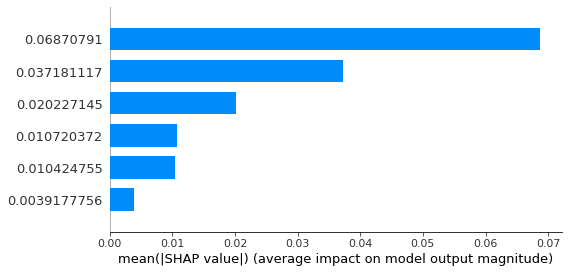

In [22]:
# 返回一个numpy数组，shape=(样本数, 特征数)
shap_values = explainer.shap_values(X_train)  

# 计算每个特征的平均绝对SHAP值
shap_mean_abs = np.abs(shap_values).mean(axis=0)

# 排序并显示
importance_df = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': shap_mean_abs
}).sort_values('mean_abs_shap', ascending=False)

print(importance_df)

shap.summary_plot(shap_values, shap_mean_abs, plot_type="bar")

## 全局解释(2)：特征影响分布-蜂群图

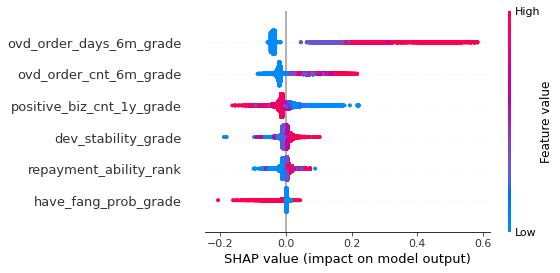

In [23]:
# 生成蜂群图
shap.summary_plot(shap_values, X_train, feature_names=X.columns)

## 全局解释(3)：特征依赖图-依赖图

                     feature  mean_abs_shap
3    ovd_order_days_6m_grade       0.068708
2     ovd_order_cnt_6m_grade       0.037181
4  positive_biz_cnt_1y_grade       0.020227


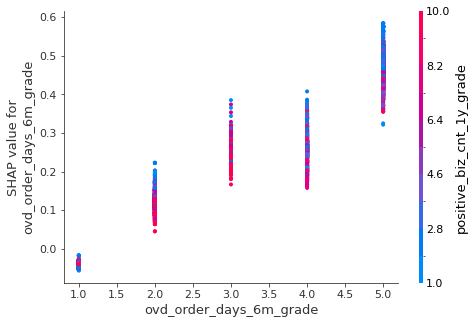

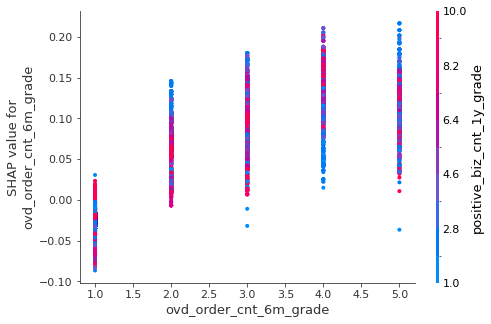

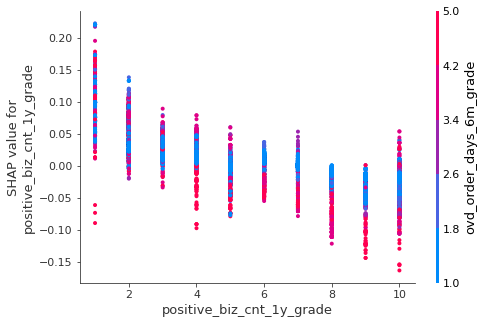

In [24]:
# 1. 先看全局重要性排名，找出最重要的前3个特征
importance_df = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print(importance_df.head(3))

# 2. 对最重要的特征画依赖图
for feat in importance_df.head(3)['feature']:
    shap.dependence_plot(feat, shap_values, X_train, feature_names=X.columns)

## 局部解释

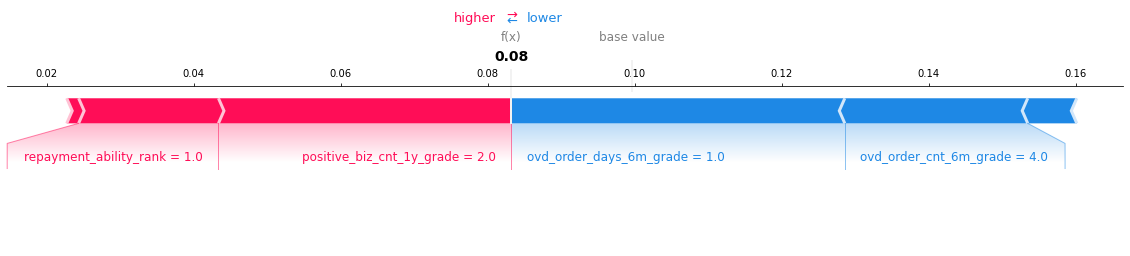

In [25]:
# 选择测试集中的第0个样本
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:], matplotlib=True)

**红色和蓝色代表的是"SHAP值的正负方向"，而箭头/条形的长度代表"影响程度的大小"。**

当前样本值小于基准值，说明被某特征推动风险（图中蓝色的两个特征，对应当前样本上的SHAP值为负数）

In [26]:
# 第0个样本的SHAP值
print(pd.DataFrame({
    'feature': X_test.columns,
    'shap_value': shap_values[0]
}))

                     feature  shap_value
0        dev_stability_grade   -0.006676
1       have_fang_prob_grade    0.001616
2     ovd_order_cnt_6m_grade   -0.024889
3    ovd_order_days_6m_grade   -0.045350
4  positive_biz_cnt_1y_grade    0.039867
5     repayment_ability_rank    0.019026


## At Last.好课推荐

更多风控好课👉[东哥讲风控](https://app7hmmvkwr2019.h5.xiaoeknow.com)

### 1）贷前策略实战项目（提高班）

贷前策略实战项目，4大真实贷前场景实战项目

内容详情介绍👉[《贷前策略实战项目（提高班）》](https://mp.weixin.qq.com/s/33nsHN3v_Zf9sPkr-yp_iA)，下单链接👉[点这里](https://bzavt.xetlk.com/s/4io33W)

### 2）pandas进阶宝典

Pandas数据分析的各种骚操作，东哥的原创笔记， 500页飞书图文笔记，近30万字，已经完全体。配套完整代码支持下载，永久访问权限。

内容详情介绍👉[《pandas进阶宝典》](https://mp.weixin.qq.com/s/9WbDFamcK2WywagdfN_f9Q)，包括5大核心图文，下单链接👉[点这里](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2YD5u0x8FzrAIyM8soEuxnTkP9r)
- 《pandas快速入门》
- 《pandas进阶宝典》
- 《pandas实战项目》
- 《pandas进阶题库》
- 《Numpy速查手册》
- 《正则表达式手册》

以上如有不清楚也可加我微信：`Petery_1966` 咨询